# Benchmark: Specialized Paths (1D, 2D, 3D) vs. Generic Fallback Path
This notebook benchmarks the performance savings of having specialized unrolled paths for 1D, 2D, and 3D charge deposition compared to a generic multidimensional fallback path (which uses loops over dimensions and corners).

Both versions share the same optimizations (early extent masking and contiguous coordinate unpacking), so this specifically measures the impact of unrolling the loops and specialized indexing.

In [1]:
import sys
import os
import time
import math
import itertools
from typing import Sequence
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import platform
import subprocess
import re
import glob

repo_root = os.path.abspath(".")
if repo_root not in sys.path:
    sys.path.append(repo_root)

import cheetah.utils.cloud_in_cell as cic_tensor

device_types = ["cpu"]
if torch.backends.mps.is_available():
    device_types.append("mps")
if torch.cuda.is_available():
    device_types.append("cuda")
print(f"Devices: {device_types}")

def sync(device):
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()

Devices: ['cpu', 'mps']


In [2]:
def get_cpu_info():
    try:
        if platform.system() == "Windows":
            return platform.processor()
        elif platform.system() == "Darwin":
            return subprocess.check_output(["sysctl", "-n", "machdep.cpu.brand_string"]).decode().strip()
        elif platform.system() == "Linux":
            with open("/proc/cpuinfo", "r") as f:
                for line in f:
                    if "model name" in line:
                        return re.sub(".*model name.*:", "", line, 1).strip()
    except Exception:
        pass
    return platform.processor() or "Unknown CPU"

def get_ram_info():
    try:
        import psutil
        return f"{psutil.virtual_memory().total / (1024**3):.1f} GB"
    except ImportError:
        pass
    try:
        if platform.system() == "Darwin":
            mem_bytes = int(subprocess.check_output(["sysctl", "-n", "hw.memsize"]).decode().strip())
            return f"{mem_bytes / (1024**3):.1f} GB"
        elif platform.system() == "Linux":
            with open("/proc/meminfo", "r") as f:
                for line in f:
                    if "MemTotal" in line:
                        mem_kb = int(line.split()[1])
                        return f"{mem_kb / (1024**2):.1f} GB"
    except Exception:
        pass
    return "Unknown RAM"

def get_gpu_info():
    gpus = []
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            gpus.append(torch.cuda.get_device_name(i))
    if torch.backends.mps.is_available():
        gpus.append("Apple Silicon Integrated GPU (MPS)")
    return ", ".join(gpus) if gpus else "None"

cpu_info = get_cpu_info()
ram_info = get_ram_info()
gpu_info = get_gpu_info()
os_info = f"{platform.system()} {platform.release()}"

system_label = f"{os_info} | {cpu_info} | RAM: {ram_info}"
if gpu_info != "None":
    system_label += f" | GPU: {gpu_info}"

print("System Information:")
print(f"OS:  {os_info}")
print(f"CPU: {cpu_info}")
print(f"RAM: {ram_info}")
print(f"GPU: {gpu_info}")
print(f"Label: {system_label}")

System Information:
OS:  Darwin 25.5.0
CPU: Apple M1 Pro
RAM: 32.0 GB
GPU: Apple Silicon Integrated GPU (MPS)
Label: Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | GPU: Apple Silicon Integrated GPU (MPS)


In [3]:
def cloud_in_cell_generic_only(
    positions: torch.Tensor,
    bins: int | Sequence[int],
    extent: torch.Tensor | None = None,
    charges: torch.Tensor | None = None,
) -> torch.Tensor:
    if extent is None:
        extent = torch.stack([positions.amin(dim=-2), positions.amax(dim=-2)], dim=-1)
    if charges is None:
        charges = torch.ones_like(positions[..., 0])

    num_hist_dims = positions.shape[-1]
    histogram_shape = [bins] * num_hist_dims if isinstance(bins, int) else bins
    assert (
        len(histogram_shape) == num_hist_dims
    ), "Number of bin values must match number of position dimensions."

    vector_shape = positions.shape[:-2]
    num_histogram_bins = math.prod(histogram_shape)
    flat_charge_grid = positions.new_zeros(*vector_shape, num_histogram_bins)

    # Generic path (copied from cloud_in_cell fallback)
    in_extent = torch.ones_like(charges, dtype=torch.bool)
    for d in range(num_hist_dims):
        coord = positions[..., d]
        lim0 = extent[..., d, 0].unsqueeze(-1)
        lim1 = extent[..., d, 1].unsqueeze(-1)
        in_extent = in_extent & (coord >= lim0) & (coord <= lim1)

    masked_charges = charges * in_extent

    idx_dims = []
    frac_dims = []
    for d in range(num_hist_dims):
        coord = positions[..., d].contiguous()
        lim0 = extent[..., d, 0].unsqueeze(-1)
        lim1 = extent[..., d, 1].unsqueeze(-1)
        Nd = histogram_shape[d]
        dd = (lim1 - lim0) / Nd
        u = (coord - lim0) / dd - 0.5

        idx = u.floor().long()
        frac = u - idx

        idx_dims.append(idx)
        frac_dims.append(frac)

    strides = [math.prod(histogram_shape[d + 1 :]) for d in range(num_hist_dims)]

    for corner in itertools.product([0, 1], repeat=num_hist_dims):
        corner_idx = 0
        corner_weight = masked_charges.clone()
        for d in range(num_hist_dims):
            use_right = corner[d]
            idx = idx_dims[d] + use_right
            idx_clamped = idx.clamp(0, histogram_shape[d] - 1)
            corner_idx = corner_idx + idx_clamped * strides[d]

            mask = (idx >= 0) & (idx < histogram_shape[d])
            weight_factor = (frac_dims[d] if use_right else (1.0 - frac_dims[d])) * mask
            corner_weight = corner_weight * weight_factor

        flat_charge_grid.scatter_add_(dim=-1, index=corner_idx, src=corner_weight)

    charge_grid = flat_charge_grid.reshape(*vector_shape, *histogram_shape)
    return charge_grid

In [4]:
def setup_benchmark_inputs(dims, batch_shape, num_particles, bins, device):
    torch.manual_seed(42)
    coords = [torch.rand(*batch_shape, num_particles, device=device) * 1.8 - 0.9 for _ in range(dims)]
    positions = torch.stack(coords, dim=-1)
    charges = torch.rand(*batch_shape, num_particles, device=device)
    
    # Calculate equivalent extents
    extent_list = []
    histogram_shape = [bins] * dims if isinstance(bins, int) else bins
    for d in range(dims):
        Nd = histogram_shape[d]
        dd = 2.0 / (Nd - 1)
        extent_list.append([-1.0 - dd/2.0, 1.0 + dd/2.0])
    extent = torch.tensor(extent_list, device=device)
    
    return positions, histogram_shape, extent, charges

In [5]:
for d in [1, 2, 3]:
    pos, bins, ext, chg = setup_benchmark_inputs(d, (2, 5), 100, 10, torch.device("cpu"))
    out_spec = cic_tensor.cloud_in_cell_charge_deposition(pos, bins, ext, chg)
    out_gen = cloud_in_cell_generic_only(pos, bins, ext, chg)
    diff = torch.max(torch.abs(out_spec - out_gen))
    print(f"{d}D - Max Difference: {diff.item():.2e}")

1D - Max Difference: 0.00e+00
2D - Max Difference: 2.38e-07
3D - Max Difference: 1.19e-07


In [6]:
def run_benchmark(num_runs=10):
    results = []
    num_particles = 100000
    batch_shape = (20, 1)
    
    test_cases = [
        (1, 150, "1D"),
        (2, 150, "2D"),
        (3, 50, "3D"),
    ]
    
    for device_name in device_types:
        device = torch.device(device_name)
        for dims, bins, label in test_cases:
            pos, bins_shape, ext, chg = setup_benchmark_inputs(dims, batch_shape, num_particles, bins, device)
            
            # Warmups
            for _ in range(3):
                _ = cic_tensor.cloud_in_cell_charge_deposition(pos, bins_shape, ext, chg)
                _ = cloud_in_cell_generic_only(pos, bins_shape, ext, chg)
            sync(device)
            
            # Specialized Run
            t_spec = []
            for _ in range(num_runs):
                t0 = time.perf_counter()
                _ = cic_tensor.cloud_in_cell_charge_deposition(pos, bins_shape, ext, chg)
                sync(device)
                t_spec.append(time.perf_counter() - t0)
                
            # Generic Run
            t_gen = []
            for _ in range(num_runs):
                t0 = time.perf_counter()
                _ = cloud_in_cell_generic_only(pos, bins_shape, ext, chg)
                sync(device)
                t_gen.append(time.perf_counter() - t0)
                
            results.append({
                "Device": device_name.upper(),
                "Dimension": label,
                "Specialized (s)": np.mean(t_spec),
                "Generic Fallback (s)": np.mean(t_gen),
                "Speedup": np.mean(t_gen) / np.mean(t_spec)
            })
            
    df = pd.DataFrame(results)
    return df

df_res = run_benchmark()
df_res

,Device,Dimension,Specialized (s),Generic Fallback (s),Speedup
0,CPU,1D,0.015928,0.018315,1.149863
1,CPU,2D,0.043360,0.069878,1.611553
2,CPU,3D,0.083001,0.195480,2.355171
3,MPS,1D,0.126733,0.128126,1.010996
4,MPS,2D,0.016002,0.020039,1.252265
5,MPS,3D,0.031536,0.047814,1.516145


In [7]:
# Save results to CSV
run_data = []
for idx, row in df_res.iterrows():
    run_data.append({
        "System": system_label,
        "Device": row["Device"],
        "Dimension": row["Dimension"],
        "Specialized (s)": row["Specialized (s)"],
        "Generic Fallback (s)": row["Generic Fallback (s)"],
        "Speedup": row["Speedup"]
    })
df_run = pd.DataFrame(run_data)

system_slug = re.sub(r'[^a-z0-9]+', '_', system_label.lower()).strip('_')
results_dir = os.path.join(repo_root, "dev", "benchmark_results")
os.makedirs(results_dir, exist_ok=True)
csv_filename = os.path.join(results_dir, f"specialized_results_{system_slug}.csv")
df_run.to_csv(csv_filename, index=False)
print(f"Saved current run results to {csv_filename}")

# Read all specialized results files
all_files = glob.glob(os.path.join(results_dir, "specialized_results_*.csv"))
print(f"Found {len(all_files)} specialized benchmark results files:")
all_dfs = []
for file in all_files:
    print(f" - {os.path.basename(file)}")
    all_dfs.append(pd.read_csv(file))
combined_df = pd.concat(all_dfs, ignore_index=True)
combined_df

Saved current run results to /Users/jankaiser/Documents/DESY/cheetah/dev/benchmark_results/specialized_results_darwin_25_5_0_apple_m1_pro_ram_32_0_gb_gpu_apple_silicon_integrated_gpu_mps.csv
Found 2 specialized benchmark results files:
 - specialized_results_linux_5_14_0_687_13_1_el9_8_x86_64_amd_epyc_7513_32_core_processor_ram_503_2_gb_gpu_nvidia_a100_80gb_pcie.csv
 - specialized_results_darwin_25_5_0_apple_m1_pro_ram_32_0_gb_gpu_apple_silicon_integrated_gpu_mps.csv


,System,Device,Dimension,Specialized (s),Generic Fallback (s),Speedup
0,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CPU,1D,0.008767,0.009109,1.038995
1,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CPU,2D,0.028016,0.045873,1.637385
2,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CPU,3D,0.041154,0.068864,1.673312
3,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CUDA,1D,0.000692,0.000797,1.151491
4,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CUDA,2D,0.001350,0.001710,1.266864
5,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CUDA,3D,0.002866,0.004398,1.534335
6,Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | ...,CPU,1D,0.015928,0.018315,1.149863
7,Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | ...,CPU,2D,0.043360,0.069878,1.611553
8,Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | ...,CPU,3D,0.083001,0.195480,2.355171
9,Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | ...,MPS,1D,0.126733,0.128126,1.010996


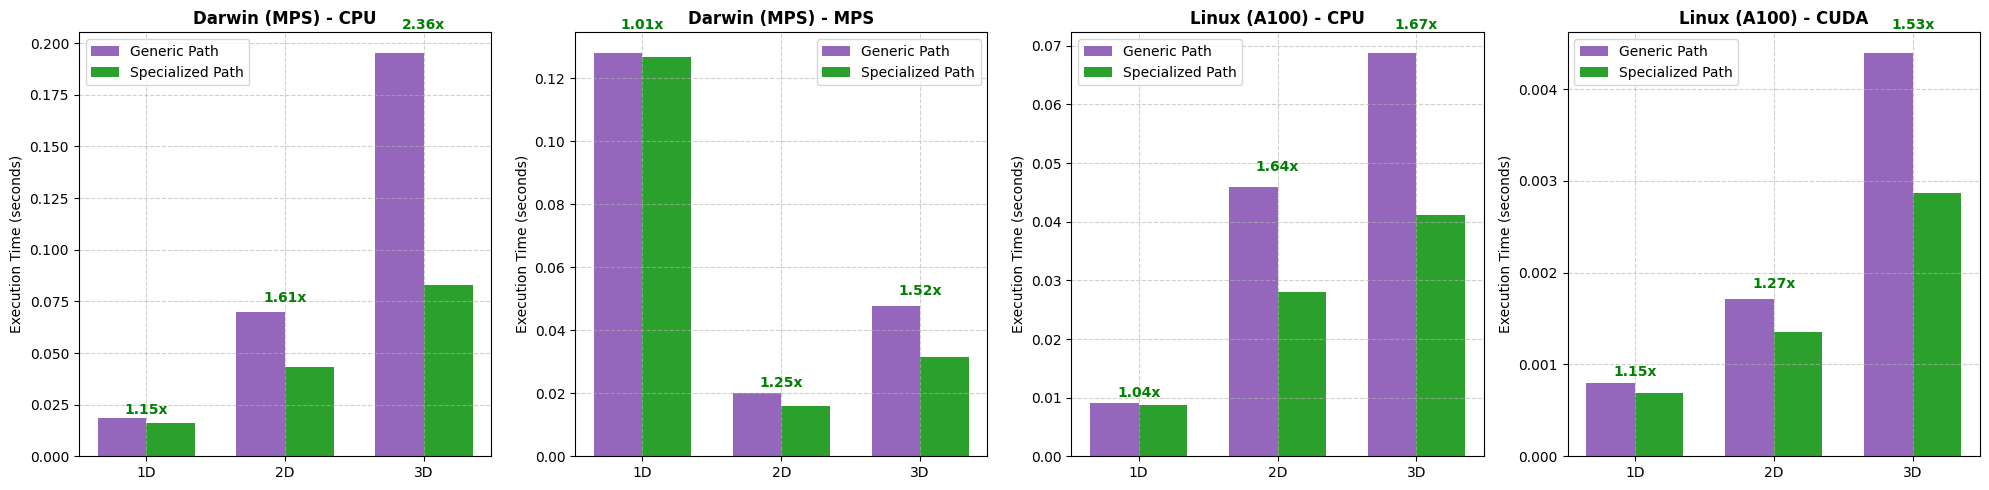

In [8]:
def plot_comparison(df):
    # Get unique system + device configurations
    configs = []
    for idx, row in df.iterrows():
        sys_name = row["System"]
        device = row["Device"]
        os_name = sys_name.split("|")[0].strip().split()[0]
        
        gpu_part = ""
        if "GPU:" in sys_name:
            gpu_name = sys_name.split("GPU:")[-1].strip()
            if "A100" in gpu_name:
                gpu_part = " (A100)"
            elif "MPS" in gpu_name:
                gpu_part = " (MPS)"
        
        label = f"{os_name}{gpu_part} - {device}"
        configs.append((sys_name, device, label))
        
    # Deduplicate configurations
    configs = list(set(configs))
    configs.sort(key=lambda x: x[2])
    
    fig, axes = plt.subplots(1, len(configs), figsize=(5 * len(configs), 5), squeeze=False)
    
    dims = ["1D", "2D", "3D"]
    
    for idx, (sys_name, dev, label) in enumerate(configs):
        ax = axes[0, idx]
        sub_df = df[(df["System"] == sys_name) & (df["Device"] == dev)]
        
        # Sort sub_df by dimension 1D, 2D, 3D
        sub_df = sub_df.set_index("Dimension").reindex(dims).reset_index()
        
        x = np.arange(len(dims))
        width = 0.35
        
        rects1 = ax.bar(x - width/2, sub_df["Generic Fallback (s)"], width, label="Generic Path", color="#9467bd")
        rects2 = ax.bar(x + width/2, sub_df["Specialized (s)"], width, label="Specialized Path", color="#2ca02c")
        
        ax.set_title(label, fontsize=12, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(dims)
        ax.set_ylabel("Execution Time (seconds)")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.6)
        
        # Add speedup label on top of bars
        for i in range(len(dims)):
            val = sub_df["Speedup"].iloc[i]
            max_val = max(sub_df["Generic Fallback (s)"].iloc[i], sub_df["Specialized (s)"].iloc[i])
            ax.text(i, max_val * 1.05,
                    f"{val:.2f}x", ha="center", va="bottom", color="green", fontweight="bold")
            
    plt.tight_layout()
    plt.savefig("specialized_paths_comparison.png", dpi=300)
    plt.show()

plot_comparison(combined_df)